<a href="https://colab.research.google.com/github/minhfua/FACE-RECOGNITION-APP/blob/main/%5BAPP_NH%E1%BA%ACN_DI%E1%BB%86N_KHU%C3%94N_M%E1%BA%B6T_TRONG_L%E1%BB%9AP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Dropout, Flatten
from keras.datasets import mnist # Keep import for general usage, but data loading moves

In [ ]:
import numpy as np
from keras.utils import to_categorical
from keras.datasets import mnist # Ensure mnist is imported here to load data

# Load the raw MNIST dataset directly in this cell to ensure consistent data state
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = mnist.load_data()

# Reshape x_train and x_test to include the channel dimension and normalize
# MNIST images are grayscale, so add a single channel dimension (from 28x28 to 28x28x1)
x_train = x_train_raw.reshape(-1, 28, 28, 1).astype('float32') / 255
x_test = x_test_raw.reshape(-1, 28, 28, 1).astype('float32') / 255

# One-hot encode y_train and y_test using the raw integer labels
y_train = to_categorical(y_train_raw, num_classes=10)
y_test = to_categorical(y_test_raw, num_classes=10)

In [ ]:
model= Sequential([
    Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])
history = model.fit(x_train,y_train,epochs=10,validation_data=(x_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9552 - loss: 0.1423 - val_accuracy: 0.9817 - val_loss: 0.0518
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9864 - loss: 0.0446 - val_accuracy: 0.9896 - val_loss: 0.0334
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9906 - loss: 0.0313 - val_accuracy: 0.9868 - val_loss: 0.0417
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 33ms/step - accuracy: 0.9926 - loss: 0.0245 - val_accuracy: 0.9901 - val_loss: 0.0303
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9943 - loss: 0.0195 - val_accuracy: 0.9903 - val_loss: 0.0303
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9955 - loss: 0.0156 - val_accuracy: 0.9893 - val_loss: 0.0398
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 78s 28ms/step - accuracy: 0.9964 - loss: 0.0126 - val_accuracy: 0.9887 - val_loss: 0.0430
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 30ms/step - accuracy: 0.9973 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9913 - loss: 0.0444
Độ chính xác kiểm tra: 0.9913


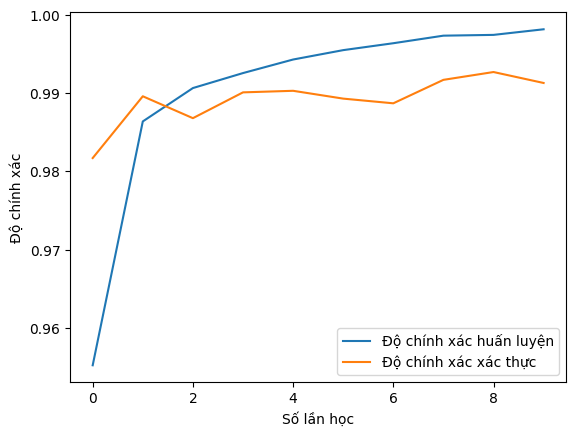

In [ ]:
import matplotlib.pyplot as plt
test_loss,test_acc = model.evaluate(x_test,y_test)
print(f"Độ chính xác kiểm tra: {test_acc:.4f}")

plt.plot(history.history['accuracy'],label='Độ chính xác huấn luyện')
plt.plot(history.history['val_accuracy'], label="Độ chính xác xác thực")
plt.xlabel('Số lần học')
plt.ylabel('Độ chính xác')
plt.legend()
plt.show()

In [ ]:
import cv2
# Read 3-chnel image
img = cv2.imread('/content/so1(paint).png')
img_rgb=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Transfer grayscale
img_gray= cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
img_gray= cv2.resize(img_gray, (28,28))
img_inverted= 255 - img_gray

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

img_ready = img_inverted.astype('float32')
img_ready = img_ready/ 255
preds = model.predict(img_ready)
digit = np.argmax(preds)
plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Anh goc (RGB)')

plt.subplot(1,2,2)
plt.imshow(img_inverted, cmap='gray')
plt.title(f"Du doan: {digit}")

ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(28, 28), dtype=float32) with name 'keras_tensor_16' and path ''. Expected shape (None, 28, 28, 1), but input has incompatible shape (28, 28)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(28, 28), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
from keras.datasets import cifar10
(x_train, y_train),(x_test,y_test) = cifar10.load_data()
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255
from keras.utils import to_categorical
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)



In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [ ]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D())
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense( 1000, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5,batch_size=200)
model.summary()

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 73s 288ms/step - accuracy: 0.3679 - loss: 1.7687
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 81s 283ms/step - accuracy: 0.5304 - loss: 1.3347
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 80s 274ms/step - accuracy: 0.6092 - loss: 1.1209
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 275ms/step - accuracy: 0.6622 - loss: 0.9765
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 276ms/step - accuracy: 0.7031 - loss: 0.8520


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1000)           │     2,305,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,806 (17.81 MB)

 Trainable params: 2,334,402 (8.91 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,334,404 (8.91 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


array([5])

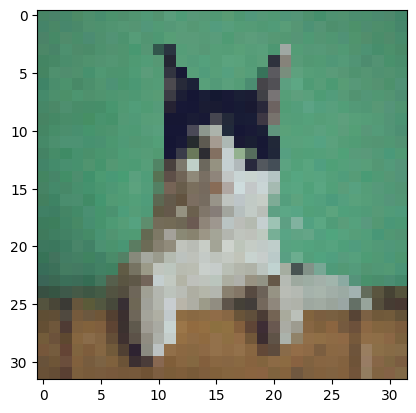

In [ ]:
from keras.utils import load_img, img_to_array #Tải ảnh
img=load_img('/content/cat_for_prediction.jpg', target_size=(32, 32))
plt.imshow(img)
# Chuyển thành mảng
img = img_to_array(img)
#Định dạng thành mẫu dữ liệu với 3 kênh
img = img.reshape(1, 32,32,3)
# Chuẩn bị dữ liệu dạng pixel
img = img.astype('float32')
img = img / 255.0
np.argmax(model.predict(img), axis=-1)

In [12]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
# 1. TIÊN XỬ LÝ DỮ LIEU
# Thiết lập đường dẫn dỡ liệu
train_dir = "/content/drive/MyDrive/60 tấm selfies - sáng T2"
# Kích thước ảnh và kích thước lô
img_width, img_height = 128, 128
batch_size = 32
# Tăng cường dữ liệu dành cho huấn luyện mô hình
train_datagen = ImageDataGenerator(
rescale=1.0/255,
rotation_range=30,
width_shift_range=0.2,
height_shift_range=0.2,
shear_range=0.2,
zoom_range=0.2,
horizontal_flip= True,
fill_mode="nearest"
)

In [13]:
# Tăng cường dữ liệu cho tập xác thực (chỉ thay đổi kích thước, không tăng cường mạnh)
# Cần thiết lập validation_split trong train_datagen hoặc tạo datagen riêng cho validation.
# Với cùng một thư mục, chúng ta có thể dùng validation_split

train_datagen_with_val = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip= True,
    fill_mode="nearest",
    validation_split=0.2 # Tách 20% dữ liệu để xác thực
)

# Tải dữ liệu huấn luyện
train_generator = train_datagen_with_val.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset='training'
)

# Tải dữ liệu xác thực
validation_generator = train_datagen_with_val.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset='validation'
)

Found 1036 images belonging to 22 classes.
Found 257 images belonging to 22 classes.


In [18]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Tải dã liệu huấn luyện
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical"
)
# XÂY DỰNG MÔ HÌNH CNN
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D (2,2),
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5), # Reduce overfitting
    Dense(64, activation="relu"), # Add another dense layer
    Dropout(0.3), # Add another dropout layer to further reduce overfitting
    Dense(22, activation="softmax") # Corrected to 22 categories to match train_generator
])

Found 1293 images belonging to 22 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 22)             │         1,430 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,314,326 (12.64 MB)

 Trainable params: 3,314,326 (12.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.6937 - loss: 0.9403
Epoch 2/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.7115 - loss: 0.8360
Epoch 3/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.7123 - loss: 0.8685
Epoch 4/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.7138 - loss: 0.8936
Epoch 5/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.7169 - loss: 0.8694
Epoch 6/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.7463 - loss: 0.7825
Epoch 7/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.7448 - loss: 0.7909
Epoch 8/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.7239 - loss: 0.8457
Epoch 9/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.7216 - loss: 0.8092
Epoch 10/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.7417 - loss: 0.7634
Epoch 11/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.7456 - loss: 0.7450
Epoch 12/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.7541 - lo

KeyError: 'val_accuracy'

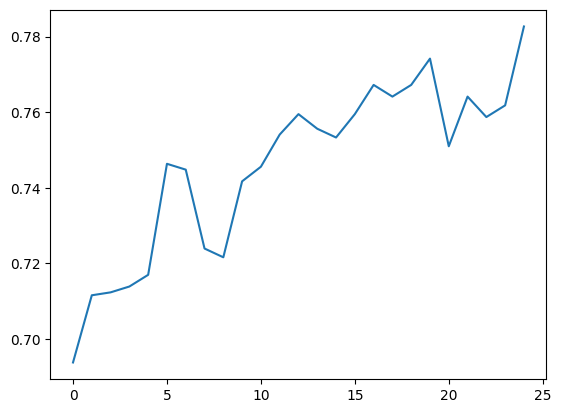

In [27]:
# Biên dịch mô hình
model.compile(optimizer="adam",
loss= "categorical_crossentropy", metrics=["accuracy"])
# Tóm tắt cấu hình của mô hình
model.summary()
# HUẤN LUYỆN MÔ HÌNH CNN
epochs = 25
history = model.fit(train_generator,epochs=epochs)
#/ ĐÁNH GIÁ KẾT QUẢ MỖ HÌNH
plt.plot(history.history['accuracy'], label="Kết quả huấn luyện")
plt.plot(history.history["val_accuracy"], label="Độ chính xác xác thực")
plt.xlabel("Số lần học")
plt.ylabel("Độ chính xác")
plt.legend()
plt.show()

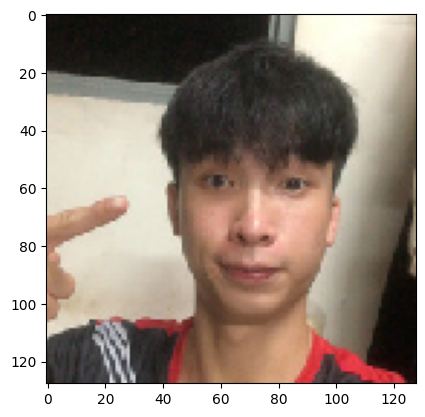

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
Người tiên đoán: Nguyễn Tiến Mạnh


In [32]:
# Tải và tiền xử lý ảnh kiểm tra
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt # Import matplotlib for plt

path = "/content/drive/MyDrive/60 tấm selfies - sáng T2/Nguyễn Tiến Mạnh/11.jpg"
img = load_img(path, target_size=(128, 128))
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 128, 128, 3)
prediction=np.argmax(model.predict(img))

# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}

if class_labels:
    person_name = class_labels[prediction]
    print(f"Người tiên đoán: {person_name}")
else:
    print("Không thể tiên đoán tên người. Không tìm thấy nhãn lớp trong train_generator.class_indices.")
    print(f"Predicted class index: {prediction}")
    print("Vui lòng kiểm tra lại đường dẫn và cấu trúc thư mục của dữ liệu huấn luyện.")